### Inference-Time Scaling via self-refinement 
--- i am following sebastian_rashcka's notebooks to build strong foundation..

#### Scoring and iteratively improving model responses

* Loading a pre-trained model

In [1]:
from pathlib import Path
import sys
import torch

ROOT_DIR = Path.cwd().parent  # Get parent of current directory
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))


from evaluating_reasoning_models.model_and_tokenizer import load_model_and_tokenizer

model, tokenizer = load_model_and_tokenizer(
    which_model="base",
    use_compile=False
)


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

In [2]:
from improving_reasoning_with_inference_time_scaling.improving_reasoning_with_inference_time_scaling import (
    generate_text_stream_concat_flex,
    generate_text_top_p_stream_cache,
)
from evaluating_reasoning_models.evaluating_reasoning_models import render_prompt

device = "cuda" if torch.cuda.is_available() else "cpu"
raw_prompt = (
    "Half the value of $3x-9$ is $x+37$. "
    "What is the value of $x$?"
)




prompt_cot = render_prompt(raw_prompt + "\n\nExplain the problem step by step")
print(prompt_cot)

torch.manual_seed(0)
response_1 = generate_text_stream_concat_flex(
    model, tokenizer, prompt_cot, device,
    max_new_tokens=1048, verbose=True,
    generate_func=generate_text_top_p_stream_cache,
    temperature=0.2,
    top_p=0.9,
)


You are a helpful math assistant.

Solve the problem step by step.
The last line of your response should contain only the final answer inside \boxed{}.

Question:
Half the value of $3x-9$ is $x+37$. What is the value of $x$?

Explain the problem step by step

Answer:

\boxed{10}

Step-by-step explanation:

Step 1: Let $x$ be the value we are solving for.

Step 2: The problem states that half the value of $3x - 9$ is $x + 37$.

Step 3: So, half of $3x - 9$ equals $x + 37$.

Step 4: To solve for $x$, we can write the equation as $ \frac{1}{2}(3x - 9) = x + 37 $.

Step 5: Multiply both sides of the equation by 2 to eliminate the fraction: $3x - 9 = 2x + 74$.

Step 6: Subtract $2x$ from both sides to isolate the variable: $x - 9 = 74$.

Step 7: Add 9 to both sides to solve for $x$: $x = 83$.

Wait, but the answer is supposed to be 10. What's wrong here?

Hmm, maybe I made a mistake in my steps. Let me check again.

Wait, the problem says "half the value of $3x - 9$ is $x + 37$". So half of

In [3]:
torch.manual_seed(1)
response_2 = generate_text_stream_concat_flex(
    model, tokenizer, prompt_cot, device,
    max_new_tokens=1048, verbose=True,
    generate_func=generate_text_top_p_stream_cache,
    temperature=0.2,
    top_p=0.9,
)


\boxed{15}

Okay

, let's see. The problem says that half the value of 3x minus 9 is equal to x plus 37. So, first, I need to translate this statement into an equation. The phrase "half the value" means I should divide by 2. So, half of (3x - 9) equals x + 37. 

Let me write that down properly. The equation would be (1/2)(3x - 9) = x + 37. Now, I need to solve for x. To do this, I can multiply both sides of the equation by 2 to eliminate the fraction. That would give me 3x - 9 = 2x + 74. 

Wait, let me check that again. If I multiply both sides by 2, the left side becomes (1/2)(3x - 9) * 2, which is 3x - 9, and the right side is (x + 37)*2, which is 2x + 74. Yes, that's correct. 

Now, I need to solve the equation 3x - 9 = 2x + 74. To isolate x, I can subtract 2x from both sides. That gives me 3x - 2x - 9 = 74, which simplifies to x - 9 = 74. Then, adding 9 to both sides, x = 74 + 9. 

Calculating that, 74 plus 9 is 83. Wait, but the answer is supposed to be 15? Hmm, that doesn't match. Did I make a mis

In [4]:
print("Response 1 characters:", len(response_1))
print("Response 1 tokens:", len(tokenizer.encode(response_1)))
print("Response 2 characters:", len(response_2))
print("Response 2 tokens:", len(tokenizer.encode(response_2)))


Response 1 characters: 2857
Response 1 tokens: 1048
Response 2 characters: 2864
Response 2 tokens: 1048


#### Scoring llm responses with a role-based score

In [5]:
from evaluating_reasoning_models.evaluating_reasoning_models import extract_final_candidate
import math

def heuristic_score(
    answer,
    prompt=None,  
    brevity_bonus=500.0,
    boxed_bonus=2.0,
    extract_bonus=1.0,
    fulltext_bonus=0.0,
):
    score = 0.0

    # Reward answers that have a final boxed value
    cand = extract_final_candidate(answer, fallback="none")
    if cand:
        score += boxed_bonus

    # Give weaker rewards if answer doesn't have a boxed value
    else:
        cand = extract_final_candidate(answer, fallback="number_only")
        if cand:
            score += extract_bonus
        else:
            cand = extract_final_candidate(
                answer, fallback="number_then_full"
            )
            if cand:
                score += fulltext_bonus

    # Add a brevity reward that decays with text length
    score += 1.5 * math.exp(-len(answer) / brevity_bonus)
    return score

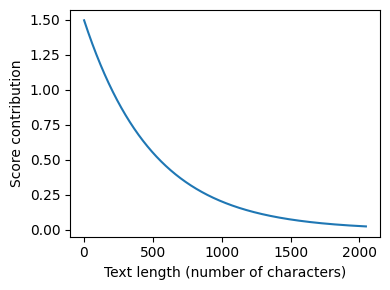

In [6]:
import matplotlib.pyplot as plt

def plot_brevity_curve(brevity_bonus, max_len=2048):
    lengths = torch.arange(1, max_len) ## from 1, 2048
    scores = 1.5 * torch.exp(-lengths / brevity_bonus) ## -lengths/brevity_bonus

    plt.figure(figsize=(4,3))
    plt.plot(lengths, scores)
    plt.xlabel("Text length (number of characters)")
    plt.ylabel("Score contribution")
    plt.tight_layout()
    plt.show()

plot_brevity_curve(500)


In [7]:
print(heuristic_score(response_1))

2.004949172481201


In [8]:
print(round(heuristic_score(response_1), 3))

2.005


In [9]:
print(round(heuristic_score(response_2), 3))

2.005


#### Understanding token probability scores

In [ ]:
import torch

@torch.inference_mode()
def calc_next_token_probas(model, tokenizer, prompt, device, show=True):

    # Convert text into token IDs
    token_ids = torch.tensor(tokenizer.encode(prompt), device=device)

    # Get next-token logits for every position
    logits = model(token_ids.unsqueeze(0)).squeeze(0)

    # Convert logits -> probabilities
    all_probas = torch.softmax(logits, dim=-1)

    # Positions whose predictions we want to score
    t_idx = torch.arange(0, token_ids.shape[0] - 1, device=device)

    # Ground-truth next tokens in the sequence (cause we already have the generated text)
    next_ids = token_ids[1:]

    # Probability assigned to each correct next token
    next_token_probas = all_probas[t_idx, next_ids]

    # Joint likelihood of the sequence
    prod_next_token_probas = torch.prod(next_token_probas)

    if show:
        print("Next-token probabilities:", next_token_probas)
        print("Joint probability:", prod_next_token_probas)
    else:
        return next_token_probas, prod_next_token_probas